In [20]:
import jax
import jax.numpy as jnp
import numpy as np
import matplotlib.pyplot as plt
import importlib

import dshape
importlib.reload(dshape);

# Geometry

### Polygon with holes

p4.area = Array(8., dtype=float32)


<Axes: >

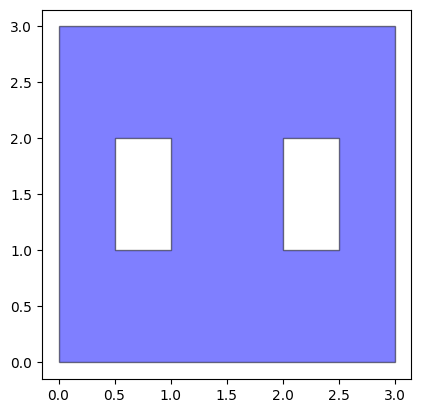

In [21]:
p1 = dshape.geometry.Rectangle(0, 0, 3, 3)
p2 = dshape.geometry.Rectangle(0.5, 1, 0.5, 1)
p3 = dshape.geometry.Rectangle(2.0, 1, 0.5, 1)

p4 = p1 - p2 - p3
print(f"{p4.area = }")
p4.plot()

### MultiPolygon

<Axes: >

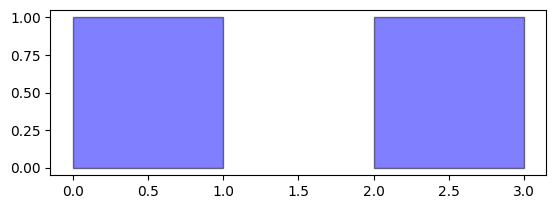

In [22]:
p1 = dshape.geometry.Rectangle(0, 0, 3, 1)
p2 = dshape.geometry.Rectangle(1, -1, 1, 3)
p3 = p1 - p2

fig, ax = plt.subplots()
p3.plot(ax=ax)

### Island in a hole 

<Axes: >

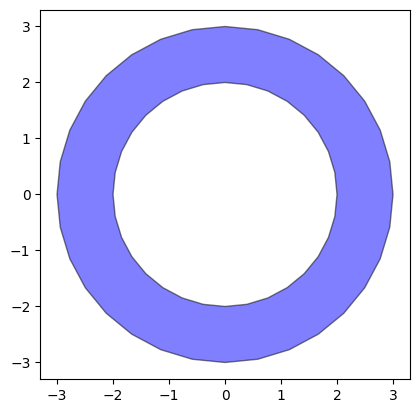

In [23]:
p1 = dshape.geometry.Circle(0, 0, 1.0)
p2 = dshape.geometry.Circle(0, 0, 2.0)
p3 = dshape.geometry.Circle(0, 0, 3.0)

p4 = (p3 - p2) + p1
p4.plot()

### Convex Hull

<Axes: >

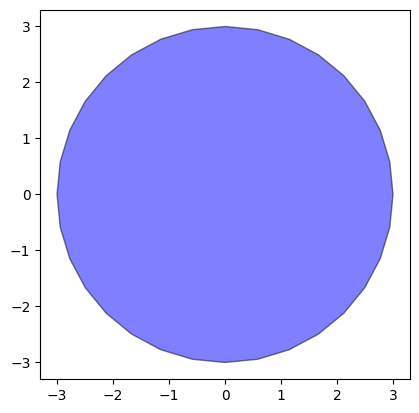

In [24]:
p4 = p3.convex_hull
p4.plot()

# Set operations

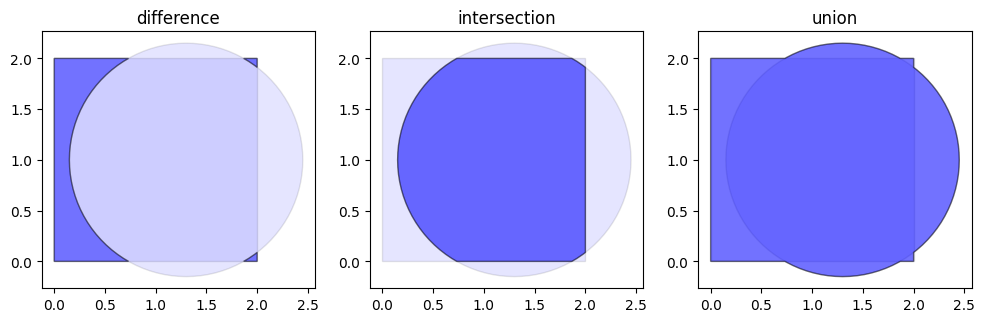

In [25]:
p1 = dshape.geometry.Rectangle(0.0, 0.0, 2.0, 2.0)
p2 = dshape.geometry.Circle(1.3, 1.0, 1.15, num_edges=100)

diff_poly = p1 - p2
intersection_poly = p1 * p2
union_poly = p1 + p2

_, ax = plt.subplots(figsize=(12, 4), ncols=3)

for i in range(3):
    ax[i].set_aspect('equal')
    p1.plot(ax[i], alpha=0.1)
    p2.plot(ax[i], alpha=0.1)

diff_poly.plot(ax[0], color='blue')
ax[0].set_title('difference')
intersection_poly.plot(ax[1], color='blue')
ax[1].set_title('intersection')
union_poly.plot(ax[2], color='blue')
ax[2].set_title('union')

plt.show()

# Mutation

### Dilation

Text(0.5, 1.0, 'Dilation')

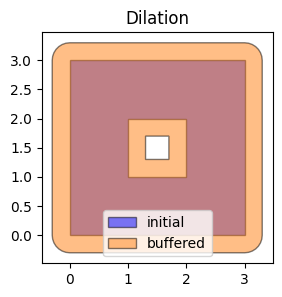

In [27]:
p1 = dshape.geometry.Rectangle(0, 0, 3, 3)
p2 = dshape.geometry.Rectangle(1, 1, 1, 1)
p3 = p1 - p2
p4 = p3.buffer(0.3)

fig, ax = plt.subplots(figsize=(3, 3))
p3.plot(ax=ax, label='initial')
p4.plot(ax=ax, color='tab:orange', label='buffered')
ax.legend()
ax.set_title('Dilation')

### Rotation

In [28]:
p1 = dshape.geometry.Rectangle(0, 0, 3, 3)
p2 = dshape.geometry.Rectangle(1, 1, 1, 1)
p3 = p1 - p2
p4 = p3.buffer(0.3)
p5 = p4.rotate(jnp.pi / 4, center=jnp.array([2.0, 1.5]))
plotting.plot_polygons([p1, p2, p3, p5])

## Scale

In [29]:
p1 = dshape.geometry.Rectangle(0, 0, 3, 3)
p2 = dshape.geometry.Rectangle(1, 1, 1, 1)
p3 = p1 - p2
p4 = p3.buffer(0.3)
p5 = p4.scale(1.5, origin=(1.5, 1.5))
plotting.plot_polygons([p1, p2, p3, p5])

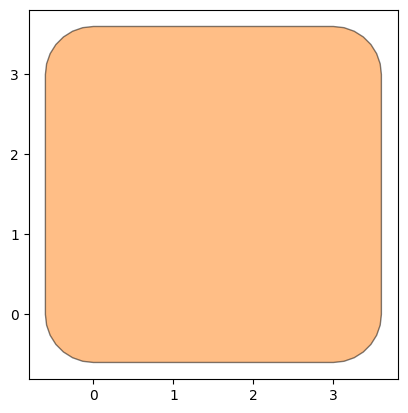

In [30]:
p1 = dshape.geometry.Rectangle(0, 0, 3, 3)
p2 = dshape.geometry.Rectangle(1, 1, 1, 1)
p3 = p1 - p2
p4 = p3.buffer(0.6)

fig, ax = plt.subplots()
p4.plot(ax=ax, color='tab:orange');

### Erosion

Text(0.5, 1.0, 'Erosion')

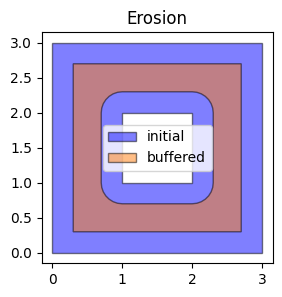

In [31]:
p1 = dshape.geometry.Rectangle(0, 0, 3, 3)
p2 = dshape.geometry.Rectangle(1, 1, 1, 1)
p3 = p1 - p2
p4 = p3.buffer(-0.3)

fig, ax = plt.subplots(figsize=(3, 3))
p3.plot(ax=ax, label="initial")
p4.plot(ax=ax, color="tab:orange", label="buffered")
ax.legend()
ax.set_title("Erosion")

### L shape

0.5795775
False


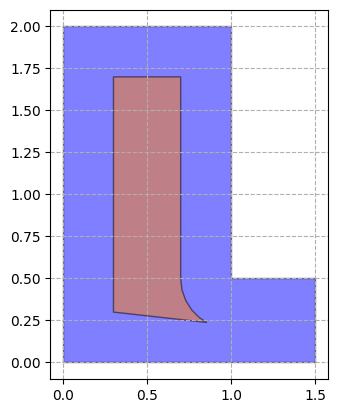

In [40]:
vertices = jnp.array(
    [[0.0, 0.0], [1.5, 0.0], [1.5, 0.5], [1.0, 0.5], [1.0, 2.0], [0.0, 2.0]],
    dtype=jnp.float32,
)
p1 = dshape.geometry.Polygon(vertices=vertices)
p2 = dshape.mutation.buffer(p1, -0.3)

fig, ax = plt.subplots()
p1.plot(ax=ax)
p2.plot(ax=ax, color='tab:orange')
print(p2.area)
print(p2.self_intersect)
ax.grid(True, linestyle='--')

# Plotting using plotly

In [35]:
p1 = dshape.geometry.Circle(0, 0, 1.15, num_edges=100)
p2 = p1.buffer(-1.0)
print(f'{p2.area = }')
plotting.plot_polygons([p1, p2])

p2.area = Array(0.0701751, dtype=float32)


# Staircase

p1.area = Array(0.5, dtype=float32)
p2.area = Array(1.306474, dtype=float32)


<Axes: >

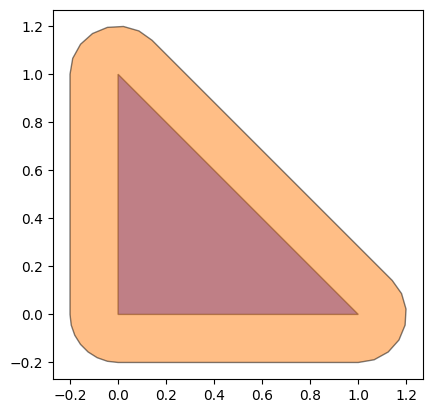

In [36]:
p1 = dshape.geometry.Polygon(
    vertices=jnp.array(
        [
            [0.0, 0.0],
            [1.0, 0.0],
            [0.0, 1.0],
        ]
    )
)
p2 = p1.buffer(0.2)
print(f"{p1.area = }")
print(f"{p2.area = }")

fig, ax = plt.subplots()
p1.plot(ax=ax)
p2.plot(ax=ax, color='tab:orange')

# Multiple staircases

p5.area = Array(1.0218873, dtype=float32)


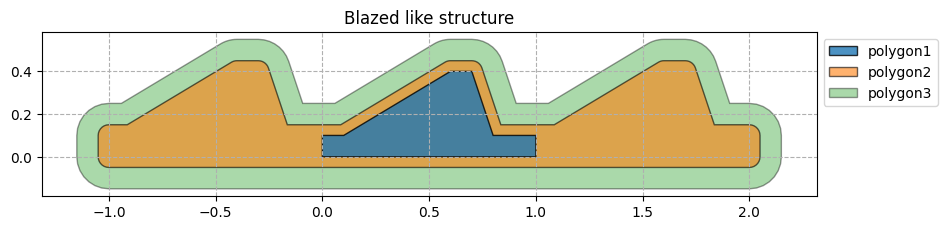

In [37]:
p1 = dshape.geometry.Polygon(
    vertices=jnp.array(
        [
            [0.0, 0.0],
            [1.0, 0.0],
            [1.0, 0.1],
            [0.8, 0.1],
            [0.7, 0.4],
            [0.6, 0.4],
            [0.1, 0.1],
            [0, 0.1],
        ]
    )
)
p2 = p1.buffer(0.05)
p3 = p2.offset(1.0, 0.0)
p4 = p2.offset(-1.0, 0.0)
p5 = p2 + p3 + p4

p2b = p1.buffer(0.15)
p3b = p2b.offset(1.0, 0.0)
p4b = p2b.offset(-1.0, 0.0)
p5b = p2b + p3b + p4b

print(f"{p5.area = }")

fig, ax = plt.subplots(figsize=(10, 4))
p5b.plot(ax=ax, label="polygon3", color="tab:green", alpha=0.4)
p5.plot(ax=ax, label="polygon2", color="tab:orange", alpha=0.6)
p1.plot(ax=ax, label="polygon1", color="tab:blue", alpha=0.8)
ax.legend(loc="upper left", bbox_to_anchor=(1.0, 1.0), reverse=True)
ax.grid(True, linestyle="dashed")
ax.set_title("Blazed like structure")

plotting.plot_polygons([p1, p5, p5b], title="Blazed like structure")